In [1]:
import pandas as pd
import numpy as np

# 1. Load the calendar
calendar = pd.read_csv('calendar.csv')
print("Calendar loaded successfully!")

# 2. Load just the first 5 items from Store CA_1 to keep it fast
sales_raw = pd.read_csv('sales_train_validation.csv')
sales_sub = sales_raw[sales_raw['store_id'] == 'CA_1'].iloc[:5]

# 3. Reshape wide columns (d_1, d_2, ...) into a clean table (date, item, sales)
id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
df_long = pd.melt(sales_sub, id_vars=id_cols, var_name='d', value_name='sales')

# 4. Merge with calendar information
df = df_long.merge(
    calendar[['d', 'date', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'snap_CA']],
    on='d',
    how='left'
)

# Convert date column to datetime format
df['date'] = pd.to_datetime(df['date'])
df['event_name_1'] = df['event_name_1'].fillna('None')

print(f"Data ready! Total rows: {len(df)}")
df.head(5)

Calendar loaded successfully!
Data ready! Total rows: 9565


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,weekday,wday,month,year,event_name_1,snap_CA
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,Saturday,1,1,2011,None,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,Saturday,1,1,2011,None,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,Saturday,1,1,2011,None,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,Saturday,1,1,2011,None,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,Saturday,1,1,2011,None,0


In [2]:
# Sort cleanly by item and date so lag calculations are exact
df = df.sort_values(['item_id', 'date']).reset_index(drop=True)

# 1. Calendar Clues
df['dayofweek'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
df['month'] = df['date'].dt.month

# 2. Lag Features (Sales from 1 day ago, 7 days ago, 14 days ago)
for lag in [1, 7, 14]:
    df[f'lag_{lag}'] = df.groupby('item_id')['sales'].shift(lag)

# 3. Rolling Statistics (Mean and Volatility over past 7 days)
# Shifted by 1 day to make sure we don't cheat by looking at today's sales
df['rolling_mean_7'] = (
    df.groupby('item_id')['sales']
    .shift(1)
    .rolling(7)
    .mean()
    .reset_index(0, drop=True)
)
df['rolling_std_7'] = (
    df.groupby('item_id')['sales']
    .shift(1)
    .rolling(7)
    .std()
    .reset_index(0, drop=True)
)

# 4. Drop the earliest rows where lags/rolling windows don't have enough history yet
df_clean = df.dropna().reset_index(drop=True)

print("Features built successfully!")
print(f"Cleaned dataset shape: {df_clean.shape}")
df_clean[['date', 'item_id', 'sales', 'lag_1', 'lag_7', 'rolling_mean_7', 'rolling_std_7']].head(5)

Features built successfully!
Cleaned dataset shape: (9495, 22)


,date,item_id,sales,lag_1,lag_7,rolling_mean_7,rolling_std_7
0,2011-02-12,HOBBIES_1_001,0,0.0,0.0,0.0,0.0
1,2011-02-13,HOBBIES_1_001,0,0.0,0.0,0.0,0.0
2,2011-02-14,HOBBIES_1_001,0,0.0,0.0,0.0,0.0
3,2011-02-15,HOBBIES_1_001,0,0.0,0.0,0.0,0.0
4,2011-02-16,HOBBIES_1_001,0,0.0,0.0,0.0,0.0


In [3]:
import lightgbm as lgb

# 1. Keep only rows where sales have started (remove leading zeros before first sale)
df_active = df_clean.copy()
# Remove periods before item had any history of non-zero sales
df_active = df_active[df_active['date'] >= '2013-01-01'].reset_index(drop=True)

# 2. Select model features (inputs) and target (what to predict)
features = ['dayofweek', 'is_weekend', 'month', 'snap_CA', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7']
target = 'sales'

# 3. Chronological Time Split (train on past, test on future)
split_date = '2015-12-01'
train_data = df_active[df_active['date'] < split_date]
test_data = df_active[df_active['date'] >= split_date]

X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

# 4. Train 3 separate Quantile LightGBM models
quantiles = [0.10, 0.50, 0.90]
models = {}
predictions = {}

for q in quantiles:
    print(f"Training model for {int(q*100)}th percentile...")
    params = {
        'objective': 'quantile',
        'alpha': q,
        'metric': 'quantile',
        'learning_rate': 0.05,
        'num_leaves': 31,
        'verbosity': -1,
        'random_state': 42
    }

    dtrain = lgb.Dataset(X_train, label=y_train)
    model = lgb.train(params, dtrain, num_boost_round=150)
    models[q] = model
    predictions[f'q_{int(q*100)}'] = model.predict(X_test)

# Put predictions into a clean dataframe
preds_df = pd.DataFrame(predictions, index=test_data.index)
# Ensure sensible ordering: 10th <= 50th <= 90th
preds_df['q_50'] = np.maximum(preds_df['q_10'], preds_df['q_50'])
preds_df['q_90'] = np.maximum(preds_df['q_50'], preds_df['q_90'])

# Attach actual sales and dates to compare
results = test_data[['date', 'item_id', 'sales']].copy()
results = results.join(preds_df)

print("\nModels trained successfully! Here is a sample of predictions vs actuals:")
results[results['sales'] > 0].head(8)

Training samples: 5320 | Testing samples: 730
Training model for 10th percentile...
Training model for 50th percentile...
Training model for 90th percentile...

Models trained successfully! Here is a sample of predictions vs actuals:


,date,item_id,sales,q_10,q_50,q_90
1065,2015-12-02,HOBBIES_1_001,1,0.0,0.782700,1.700648
1070,2015-12-07,HOBBIES_1_001,1,0.0,0.771997,1.163864
1071,2015-12-08,HOBBIES_1_001,2,0.0,0.000000,0.856050
1072,2015-12-09,HOBBIES_1_001,1,0.0,0.771997,1.495955
1078,2015-12-15,HOBBIES_1_001,1,0.0,0.670795,1.126305
1080,2015-12-17,HOBBIES_1_001,3,0.0,0.000000,0.997305
1082,2015-12-19,HOBBIES_1_001,1,0.0,1.497930,3.260233
1083,2015-12-20,HOBBIES_1_001,2,0.0,1.048765,3.053678


In [5]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import numpy as np
import pandas as pd

# Bring rolling_mean_7 over into results so we can detect spikes
results['rolling_mean_7'] = test_data['rolling_mean_7'].values

# ---------------------------------------------------------
# 1. ACCURACY & CALIBRATION EVALUATION
# ---------------------------------------------------------
mae = mean_absolute_error(results['sales'], results['q_50'])
rmse = root_mean_squared_error(results['sales'], results['q_50'])

# Empirical coverage: fraction of actual sales falling within [q_10, q_90]
covered = (results['sales'] >= results['q_10']) & (results['sales'] <= results['q_90'])
empirical_coverage = covered.mean()

print("=" * 45)
print("1. MODEL ACCURACY & CALIBRATION METRICS")
print("=" * 45)
print(f"Point Forecast MAE  : {mae:.2f}")
print(f"Point Forecast RMSE : {rmse:.2f}")
print(f"Target Coverage     : 80.00%")
print(f"Empirical Coverage  : {empirical_coverage * 100:.2f}%")

# ---------------------------------------------------------
# 2. INVENTORY DECISION SIMULATION
# ---------------------------------------------------------
# Cost rules: holding 1 unsold unit costs $1; stocking out costs $5 per unit
holding_unit_cost = 1.0
stockout_unit_cost = 5.0

def calculate_costs(orders, actuals):
    overstock = np.maximum(0, orders - actuals)
    stockouts = np.maximum(0, actuals - orders)

    holding_cost = overstock * holding_unit_cost
    stockout_cost = stockouts * stockout_unit_cost
    total_cost = (holding_cost + stockout_cost).sum()
    stockout_days = (stockouts > 0).sum()

    return total_cost, holding_cost.sum(), stockout_cost.sum(), stockout_days

cost_q50, h_q50, s_q50, days_q50 = calculate_costs(results['q_50'], results['sales'])
cost_q90, h_q90, s_q90, days_q90 = calculate_costs(results['q_90'], results['sales'])

summary_table = pd.DataFrame({
    'Strategy': ['Point Forecast (q50)', 'Safety Stock (q90)'],
    'Total Cost ($)': [round(cost_q50, 2), round(cost_q90, 2)],
    'Holding Cost ($)': [round(h_q50, 2), round(h_q90, 2)],
    'Stockout Penalty ($)': [round(s_q50, 2), round(s_q90, 2)],
    'Stockout Days': [days_q50, days_q90]
})

print("\n" + "=" * 45)
print("2. INVENTORY DECISION PAYOFF")
print("=" * 45)
print(summary_table.to_string(index=False))

# ---------------------------------------------------------
# 3. OVERCONFIDENCE DURING DEMAND SPIKES
# ---------------------------------------------------------
# Define a spike as sales higher than 1.5x the rolling 7-day average + 1
results['is_spike'] = results['sales'] > (results['rolling_mean_7'] * 1.5 + 1)
results['missed_high'] = (results['sales'] > results['q_90']).astype(int)

spike_miss = results[results['is_spike']]['missed_high'].mean()
normal_miss = results[~results['is_spike']]['missed_high'].mean()

print("\n" + "=" * 45)
print("3. OVERCONFIDENCE DIAGNOSTICS")
print("=" * 45)
print(f"Breach Rate during Normal Days : {normal_miss * 100:.2f}%")
print(f"Breach Rate during Spike Days  : {spike_miss * 100:.2f}%")

1. MODEL ACCURACY & CALIBRATION METRICS
Point Forecast MAE  : 0.81
Point Forecast RMSE : 1.25
Target Coverage     : 80.00%
Empirical Coverage  : 83.01%

2. INVENTORY DECISION PAYOFF
            Strategy  Total Cost ($)  Holding Cost ($)  Stockout Penalty ($)  Stockout Days
Point Forecast (q50)          2243.8            176.56               2067.24            305
  Safety Stock (q90)          1517.7            953.29                564.41            119

3. OVERCONFIDENCE DIAGNOSTICS
Breach Rate during Normal Days : 8.55%
Breach Rate during Spike Days  : 84.00%


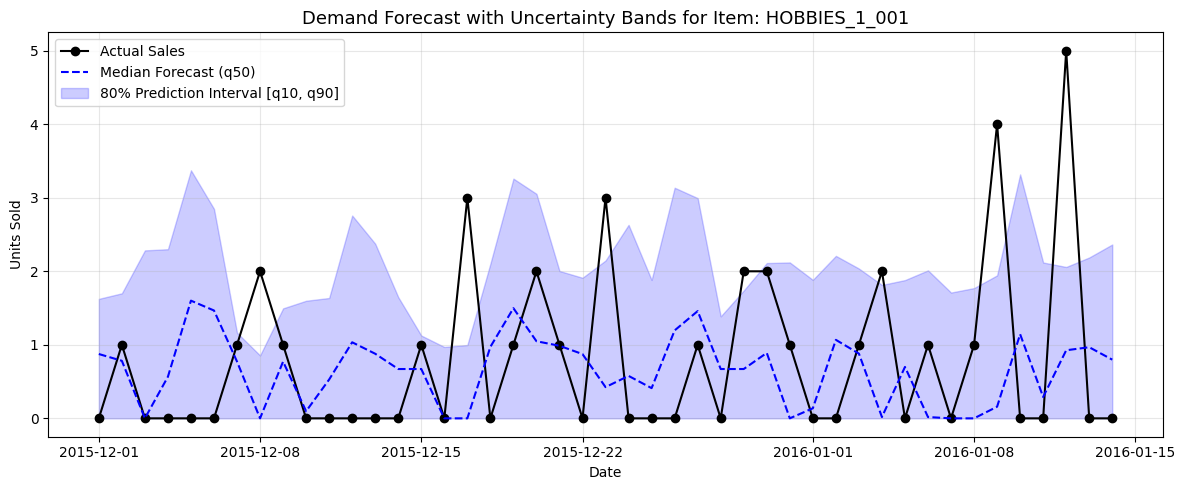

In [6]:
# Visualize forecast intervals for the first item across a 45-day window
sample_item = results['item_id'].iloc[0]
sample_view = results[results['item_id'] == sample_item].iloc[:45]

plt.figure(figsize=(12, 5))
plt.plot(sample_view['date'], sample_view['sales'], color='black', marker='o', label='Actual Sales')
plt.plot(sample_view['date'], sample_view['q_50'], color='blue', linestyle='--', label='Median Forecast (q50)')
plt.fill_between(
    sample_view['date'],
    sample_view['q_10'],
    sample_view['q_90'],
    color='blue',
    alpha=0.2,
    label='80% Prediction Interval [q10, q90]'
)

plt.title(f"Demand Forecast with Uncertainty Bands for Item: {sample_item}", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# ---------------------------------------------------------
# BONUS: RESIDUAL-BASED INTERVALS (POINT REGRESSION + ERROR BUFFER)
# ---------------------------------------------------------
# 1. Train a standard regression model (minimizes squared error / L2 loss)
point_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbosity': -1,
    'random_state': 42
}

dtrain = lgb.Dataset(X_train, label=y_train)
point_model = lgb.train(point_params, dtrain, num_boost_round=150)

# 2. Compute training error standard deviation (sigma)
train_residuals = y_train - point_model.predict(X_train)
residual_sigma = np.std(train_residuals)

# 3. Create a static +/- 1.282*sigma interval for 80% coverage on test data
z_score = 1.282
baseline_point_preds = point_model.predict(X_test)
baseline_q10 = np.maximum(0, baseline_point_preds - z_score * residual_sigma)
baseline_q90 = baseline_point_preds + z_score * residual_sigma

# 4. Measure coverage of this simple baseline
baseline_covered = (results['sales'] >= baseline_q10) & (results['sales'] <= baseline_q90)
baseline_coverage = baseline_covered.mean()

# 5. Compare against our Quantile LightGBM
comparison_df = pd.DataFrame({
    'Model Approach': ['Quantile Regression (LightGBM)', 'Naive Residual Interval (Point + Z*Std)'],
    'Nominal Target Coverage': ['80.00%', '80.00%'],
    'Empirical Coverage': [f"{empirical_coverage * 100:.2f}%", f"{baseline_coverage * 100:.2f}%"],
    'Coverage Error (Gap)': [
        f"{abs(empirical_coverage - 0.80) * 100:.2f}%",
        f"{abs(baseline_coverage - 0.80) * 100:.2f}%"
    ]
})

print("=" * 60)
print("BONUS: QUANTILE REGRESSION VS. RESIDUAL-BASED BASELINE")
print("=" * 60)
print(comparison_df.to_string(index=False))

BONUS: QUANTILE REGRESSION VS. RESIDUAL-BASED BASELINE
                         Model Approach Nominal Target Coverage Empirical Coverage Coverage Error (Gap)
         Quantile Regression (LightGBM)                  80.00%             83.01%                3.01%
Naive Residual Interval (Point + Z*Std)                  80.00%             74.25%                5.75%
